In [1]:
from pathlib import Path
import os
import json
import importlib

from dotenv import load_dotenv

load_dotenv()

import Classes.helper_classes as helper_classes
import Classes.sql2graph_classes as sql2graph_classes

# Reload during notebook dev so edits to Classes/ are picked up without restarting the kernel.
helper_classes = importlib.reload(helper_classes)
sql2graph_classes = importlib.reload(sql2graph_classes)

SQL2GraphParser = sql2graph_classes.SQL2GraphParser
SQL2GraphLLMExtractor = sql2graph_classes.SQL2GraphLLMExtractor
SQL2GraphPipeline = sql2graph_classes.SQL2GraphPipeline
SQL2GraphVisualizer = sql2graph_classes.SQL2GraphVisualizer

HF_TOKEN = os.environ.get("HF_TOKEN")
MODEL = os.environ.get("MODEL_NAME", "Qwen/Qwen3-Coder-30B-A3B-Instruct")
PROVIDER = os.environ.get("PROVIDER", "scaleway")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing. Add HF_TOKEN to .env and restart the kernel.")

print(f"HF_TOKEN loaded: ...{HF_TOKEN[-6:]}")
print(f"Model: {MODEL} ({PROVIDER})")

/Users/nikolajabramov/PycharmProjects/llm4lineage/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


HF_TOKEN loaded: ...OrZWkc
Model: Qwen/Qwen3-Coder-Next (novita)


In [2]:
data_path = Path("data") / "SQL.txt"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}")

raw_sql = data_path.read_text(encoding="utf-8")

# Simple statement splitter (good enough for initial testing)
statements = [s.strip() for s in raw_sql.split(";") if s.strip()]

print(f"Loaded {len(raw_sql):,} characters from {data_path}")
print(f"Detected {len(statements)} SQL statement(s)")
print("\nFirst statement preview:\n")
print(statements[0][:1200])

Loaded 17,834 characters from data/SQL.txt
Detected 1 SQL statement(s)

First statement preview:

INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_cred  SELECT agr.agr_cred_id,
    agr.prnt_agr_cred_id,
    agr.info_system_id,
    agr.agr_num,
    agr.grntee_agr_num,
    agr.signed_dt,
    agr.issue_crncy_id,
    agr.eks_overdraft_flag,
    agr.agr_regls_type_id,
        CASE
            WHEN (agr.eks_issue_dt IS NOT NULL) THEN agr.eks_issue_dt
            WHEN ((agr.agr_cred_type_cd = '1'::text) AND (agr.eks_transhes_issue_dt IS NOT NULL)) THEN agr.eks_transhes_issue_dt
            ELSE aco_fst_iss.optn_issue_dt
        END AS issue_dt,
    agr.close_dt,
    agr.expiration_dt,
    agr.host_agr_cred_id,
    agr.host_crm_id,
    agr.eks_agr_cred_type_id,
    agr.agr_frame_id,
    agr.eks_rvlng_flag,
    agr.issue_int_org_id,
    agr.multi_crncy_flag,
    agr.eks_old_restruct_cnt,
    agr.eks_old_prolong_cnt,
    agr.eks_contract_expiration_dt,
    NULL::text AS diff_intst_rate_flag,
    ag

In [3]:
parser = SQL2GraphParser()
llm_extractor = SQL2GraphLLMExtractor(
    model=MODEL,
    provider=PROVIDER,
    hf_token=HF_TOKEN,
    max_new_tokens=3072,
    temperature=0.0,
    max_retries=2,
    enable_refinement=True,  # second LLM pass for better quality lineage JSON
)
pipeline = SQL2GraphPipeline(
    llm_extractor=llm_extractor,
    parser=parser,
)

print("SQL2Graph pipeline initialized")

SQL2Graph pipeline initialized


In [4]:
# Try converting the first SQL statement
sql_to_test = statements[0]

result = pipeline.run(
    sql=sql_to_test,
    schema=None,
    dialect=None,
    include_visualization=True,
)

if "error" in result:
    print("ERROR:", result["error"])
    if "details" in result:
        print(result["details"])
else:
    edge_items = result["graph"].get("links", result["graph"].get("edges", []))
    is_dag = result.get("metadata", {}).get("is_dag", result["graph"].get("metadata", {}).get("is_dag"))
    print("Conversion succeeded")
    print("Warnings:", len(result.get("warnings", [])))
    print("Graph nodes:", len(result["graph"].get("nodes", [])))
    print("Graph edges:", len(edge_items))
    print("Directed acyclic (DAG):", is_dag)
    if result.get("warnings"):
        print("\nWarnings:")
        for warning in result["warnings"][:10]:
            print("-", warning)

Conversion succeeded
Warnings: 0
Graph nodes: 138
Graph edges: 79
Directed acyclic (DAG): True


In [5]:
# Inspect graph JSON and generated visualization text
if "error" not in result:
    edge_items = result["graph"].get("links", result["graph"].get("edges", []))

    print("\nWarnings:")
    for warning in result.get("warnings", []):
        print("-", warning)

    print("\nFirst 3 nodes:")
    print(json.dumps(result["graph"].get("nodes", [])[:3], indent=2))

    print("\nFirst 5 edges:")
    print(json.dumps(edge_items[:5], indent=2))

    print("\nMermaid preview (first 1200 chars):\n")
    print(result["visualization"]["mermaid"][:1200])


Warnings:

First 3 nodes:
[
  {
    "node_type": "output_column",
    "alias": "agr_cred_id",
    "expression": "agr.agr_cred_id",
    "aggregate": false,
    "window_function": false,
    "id": "output.agr_cred_id"
  },
  {
    "node_type": "source_column",
    "table_alias": "agr",
    "column": "agr_cred_id",
    "id": "agr.agr_cred_id"
  },
  {
    "node_type": "output_column",
    "alias": "prnt_agr_cred_id",
    "expression": "agr.prnt_agr_cred_id",
    "aggregate": false,
    "window_function": false,
    "id": "output.prnt_agr_cred_id"
  }
]

First 5 edges:
[
  {
    "edge_type": "DERIVED_FROM",
    "source": "agr.agr_cred_id",
    "target": "output.agr_cred_id",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",
    "source": "agr.prnt_agr_cred_id",
    "target": "output.prnt_agr_cred_id",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",
    "source": "agr.info_system_id",
    "target": "output.info_system_id",
    "key": 0
  },
  {
    "edge_type": "DERIVED_FROM",


In [6]:
# Interactive graph explorer (Plotly: pan, zoom, click nodes for details)
if "error" not in result:
    SQL2GraphVisualizer.explore(result, height="820px", backend="plotly")

In [7]:
# Optional: save the full output to disk for later inspection
output_path = Path("data") / "sql2graph_result.json"

if "error" not in result:
    output_path.write_text(json.dumps(result, indent=2), encoding="utf-8")
    print(f"Saved full SQL2Graph result to: {output_path}")

Saved full SQL2Graph result to: data/sql2graph_result.json


In [8]:
# Inspect extracted subgraphs (CTEs, JOIN blocks, UNION branches)
if "error" not in result:
    subgraphs = result.get("subgraphs", [])
    print(f"Total subgraphs: {len(subgraphs)}")

    for i, sg in enumerate(subgraphs):
        nodes = sg.get("graph", {}).get("nodes", [])
        edges = sg.get("graph", {}).get("links", sg.get("graph", {}).get("edges", []))
        print(f"[{i}] type={sg.get('type')} name={sg.get('name')} nodes={len(nodes)} edges={len(edges)}")
        sql_preview = (sg.get("sql", "") or "").replace("\n", " ")
        if sql_preview:
            print(f"     sql: {sql_preview[:140]}...")

Total subgraphs: 4
[0] type=union_block name=union_0_left nodes=67 edges=6
     sql: SELECT agr.agr_cred_id, agr.prnt_agr_cred_id, agr.info_system_id, agr.agr_num, agr.grntee_agr_num, agr.signed_dt, agr.issue_crncy_id, agr.ek...
[1] type=union_block name=union_0_right nodes=71 edges=0
     sql: SELECT core.agr_cred_id, CAST(NULL AS BIGINT) AS prnt_agr_cred_id, core.info_system_id, coa.coa_num AS agr_num, CAST(NULL AS TEXT) AS grntee...
[2] type=union_block name=union_1_left nodes=138 edges=79
     sql: SELECT agr.agr_cred_id, agr.prnt_agr_cred_id, agr.info_system_id, agr.agr_num, agr.grntee_agr_num, agr.signed_dt, agr.issue_crncy_id, agr.ek...
[3] type=union_block name=union_1_right nodes=73 edges=2
     sql: SELECT agr_cred.agr_cred_id, CAST(NULL AS BIGINT) AS prnt_agr_cred_id, agr_cred.info_system_id, agr_cred.agr_num, CAST(NULL AS TEXT) AS grnt...


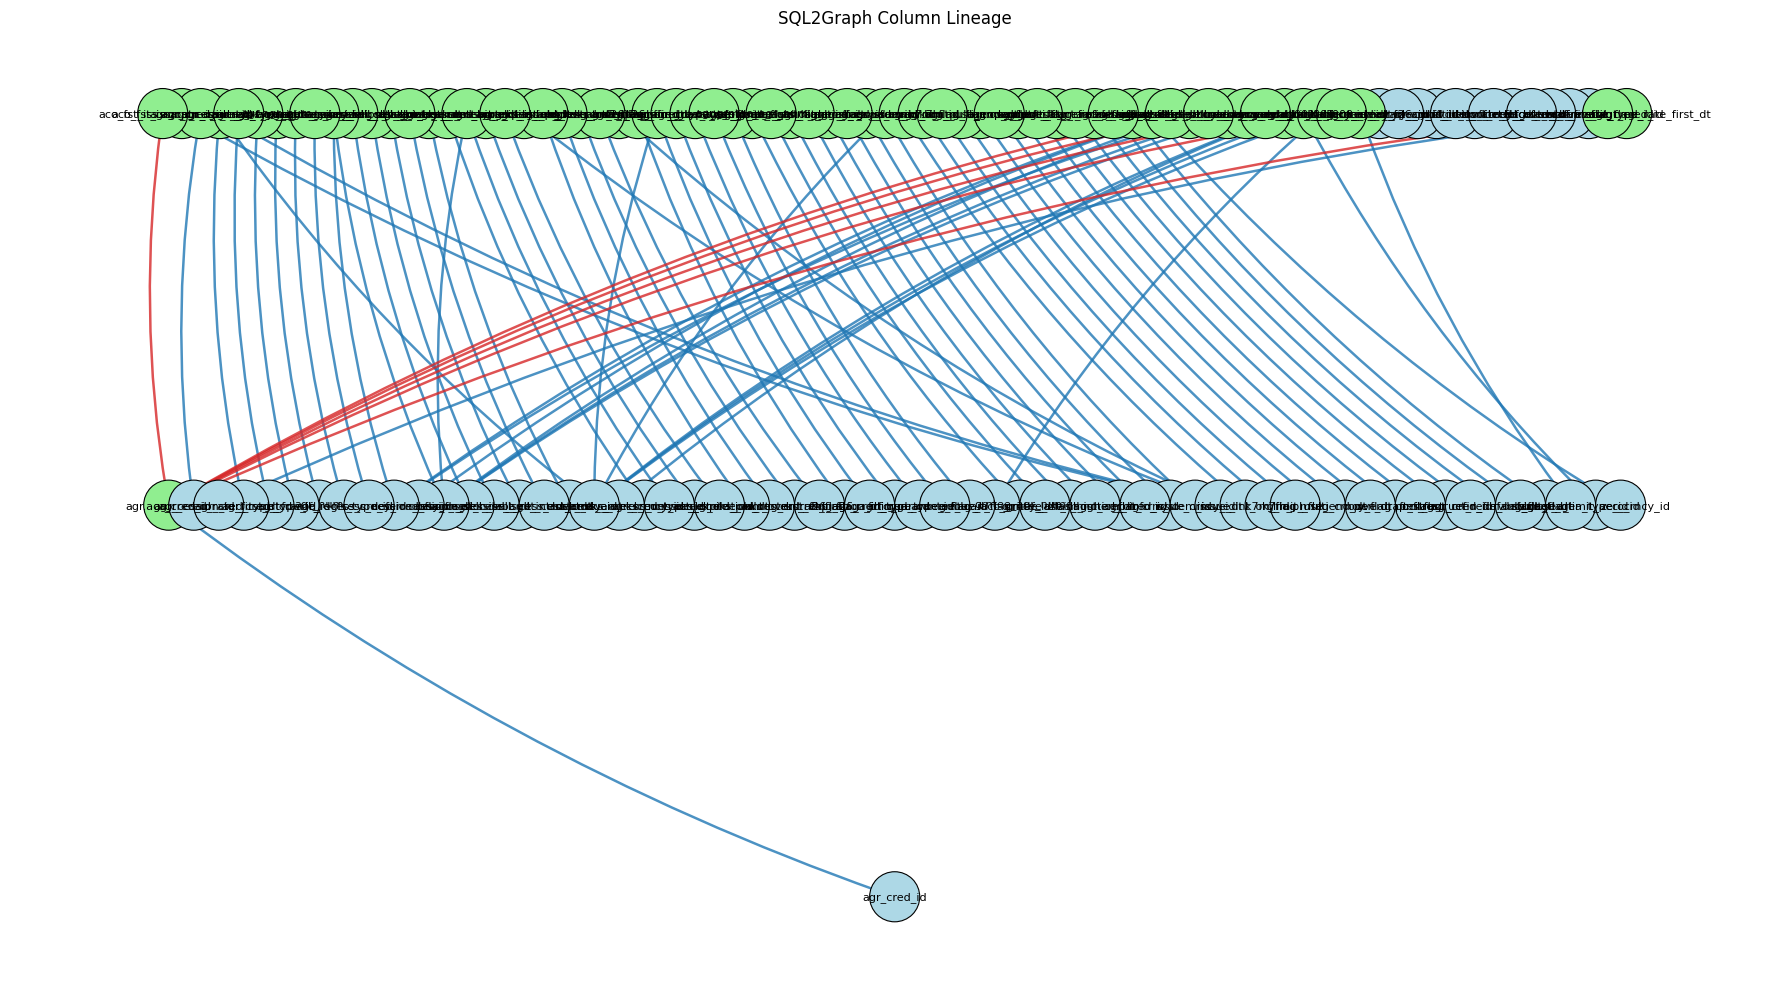

Static export: 138 nodes, 79 edges


In [9]:
# Optional static PNG export (matplotlib) for reports / slides
if "error" not in result:
    graph_obj = SQL2GraphVisualizer.draw(
        result["graph"],
        figsize=(18, 10),
        with_labels=True,
        layout="hierarchical",
    )
    print(f"Static export: {graph_obj.number_of_nodes()} nodes, {graph_obj.number_of_edges()} edges")